# 02 EDA

Denne notebooken lager en enkel, konsistent EDA pa dagsdata:
- laster data via utils
- bygger analyseklar dataframe
- sjekker manglende verdier
- lager histogrammer for malvariabler og drivere
- validerer nyhetsbrev_b7-fordeling

In [21]:
###### Unngå timeout ved oppstart
print("Hello World")

Hello World


In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve().parent.parent
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.append(str(code_dir))

from utils.data_load import load_raw_data
from utils.data_prep import data_prep

In [23]:
# Last data
NEWSLETTER_CSV = project_root / "data" / "newsletter_sendouts.csv"

df_inngang, df_info, df_weather = load_raw_data(
    session=None,
    weather_path=project_root / "data" / "oslo_weather.csv",
)

df = data_prep(
    df_inngang=df_inngang,
    df_info=df_info,
    df_weather=df_weather,
    cols_to_remove=None,
    newsletter_dates_csv=str(NEWSLETTER_CSV),
)

print("Prepared shape:", df.shape)
print("Dato fra/til:", df["ankomst_dato"].min(), "->", df["ankomst_dato"].max())
df.head(3)

Prepared shape: (499, 140)
Dato fra/til: 2024-06-03 -> 2026-06-02


,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,hf_dato,antall_nye_kunder_b30_mpb01_ny,...,antall_hf_b30_tot,antall_nye_kunder_f30_ny,antall_nye_kunder_f30_for,antall_hf_f30_ny,antall_hf_f30_for,stddev_premieendring_f30_for,snitt_premieendring_f30_for,antall_nye_kunder_f30_tot,antall_hf_f30_tot,nyhetsbrev_b7
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,2024-06-03,501,...,19452.0,665.0,665.0,4455.0,16293.0,6.548958,1.123958,1330.0,20748.0,1
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,2024-06-04,502,...,19484.0,675.0,675.0,4501.0,16287.0,6.561404,1.123967,1350.0,20788.0,1
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598,2024-06-05,488,...,19489.0,700.0,700.0,4592.0,16222.0,6.303373,1.122596,1400.0,20814.0,1


In [24]:
# Manglende verdier
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Kolonner med manglende verdier:", len(missing))
missing.head(25)

Kolonner med manglende verdier: 17


helligdag                         479
antall_nye_kunder_f30_tot          44
antall_nye_kunder_b30_ny           44
antall_hf_f30_tot                  44
antall_hf_f7_epf01_ny              44
antall_hf_b30_epf01_ny             44
antall_hf_b7_epf01_ny              44
antall_hf_f30_epf01_ny             44
antall_nye_kunder_b7_epf01_ny      44
antall_nye_kunder_f30_epf01_ny     44
antall_nye_kunder_b30_epf01_ny     44
antall_nye_kunder_b30_tot          44
antall_hf_f30_ny                   44
antall_hf_b30_tot                  44
antall_hf_b30_ny                   44
antall_nye_kunder_f7_epf01_ny      44
antall_nye_kunder_f30_ny           44
dtype: int64

In [25]:
print(df.loc[df["er_dag_etter_helligdag"]==1, ["ankomst_dato", "er_dag_foer_helligdag", "er_dag_etter_helligdag"]])

    ankomst_dato  er_dag_foer_helligdag  er_dag_etter_helligdag
90    2024-10-07                      0                       1
147   2024-12-27                      0                       1
149   2025-01-02                      0                       1
186   2025-02-24                      0                       1
221   2025-04-14                      0                       1
224   2025-04-22                      0                       1
231   2025-05-02                      0                       1
250   2025-05-30                      0                       1
256   2025-06-10                      0                       1
339   2025-10-06                      0                       1
398   2026-01-02                      0                       1
434   2026-02-23                      0                       1
459   2026-03-30                      0                       1
462   2026-04-07                      0                       1
488   2026-05-15                      0 

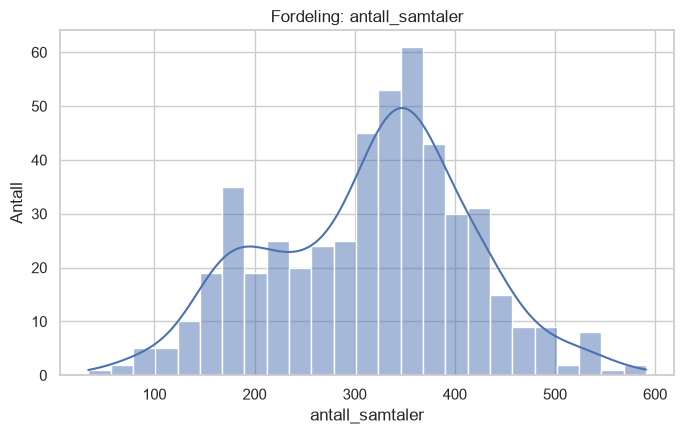

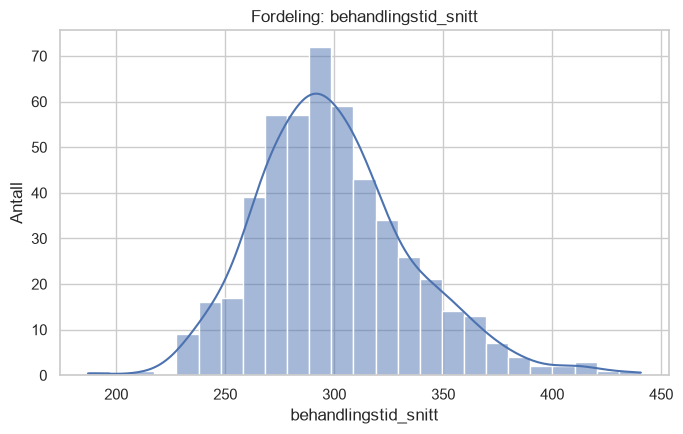

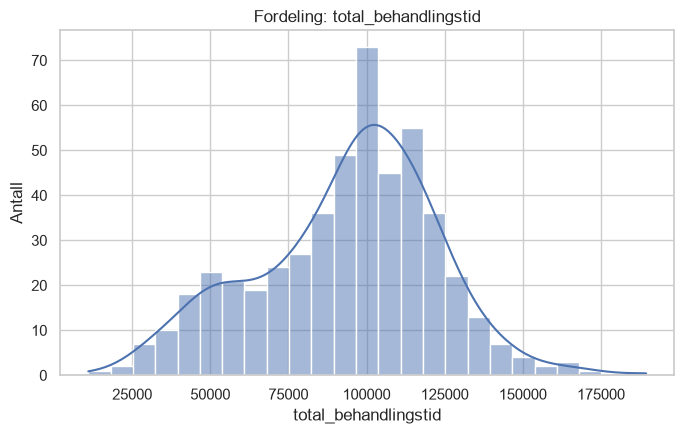

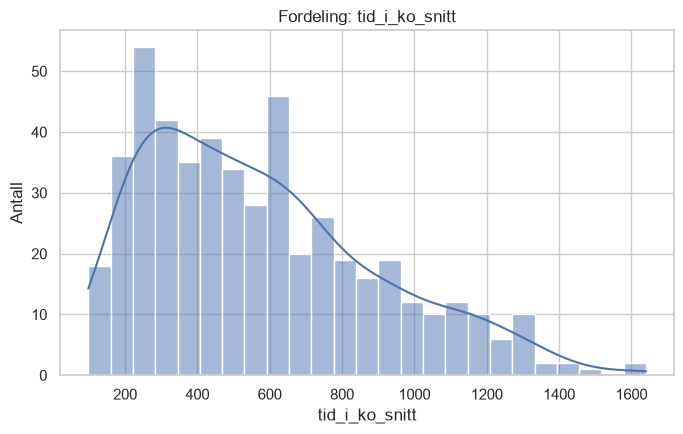

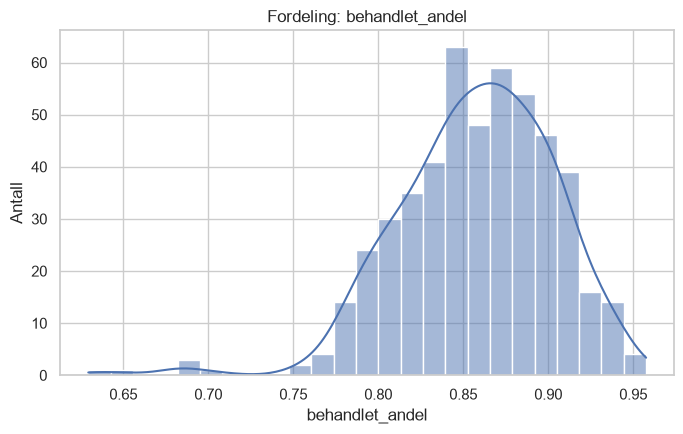

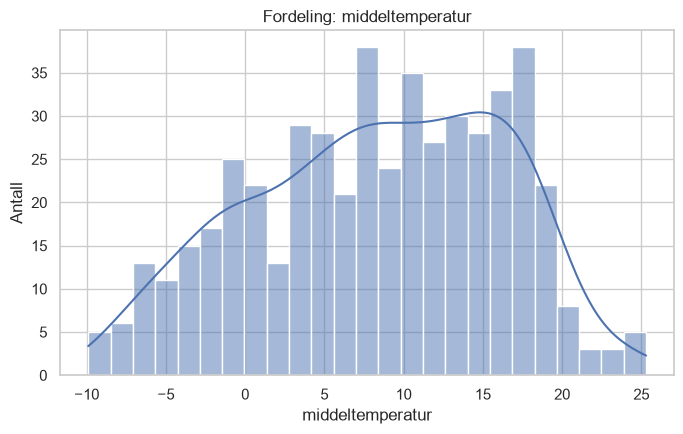

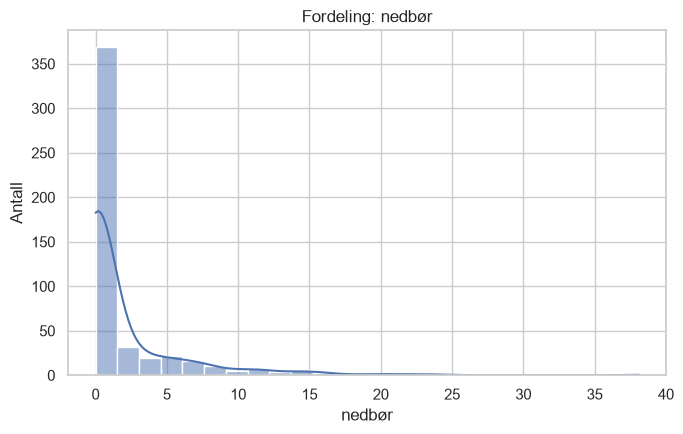

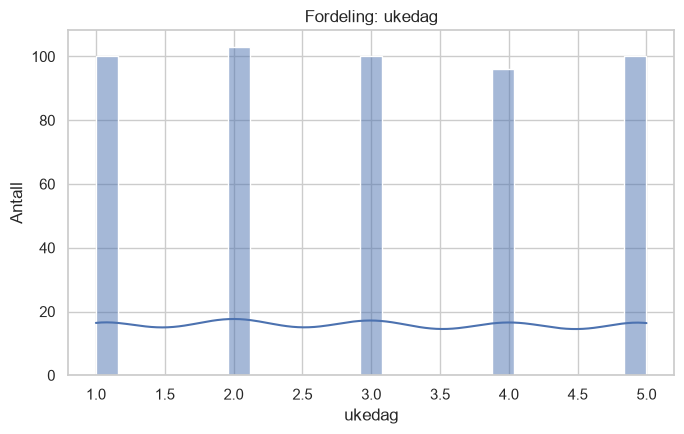

In [26]:
# Histogrammer: malvariabler + drivere (en figur per variabel)
hist_cols = [
    "antall_samtaler",
    "behandlingstid_snitt",
    "total_behandlingstid",
    "tid_i_ko_snitt",
    "behandlet_andel",
    "middeltemperatur",
    "nedbør",
    "ukedag"
]

available_hist_cols = [col for col in hist_cols if col in df.columns]

for col in available_hist_cols:
    plt.figure(figsize=(7, 4.5))
    sns.histplot(df[col].dropna(), bins=25, kde=True, color="#4C72B0")
    plt.title(f"Fordeling: {col}")
    plt.xlabel(col)
    plt.ylabel("Antall")
    plt.tight_layout()
    plt.show()

In [27]:
display(df.columns)

Index(['ankomst_dato', 'antall_samtaler', 'behandlet_andel', 'tid_i_ko_snitt',
       'behandlingstid_snitt', 'total_behandlingstid',
       'etterbehandligstid_snitt', 'total_etterbehandligstid', 'hf_dato',
       'antall_nye_kunder_b30_mpb01_ny',
       ...
       'antall_hf_b30_tot', 'antall_nye_kunder_f30_ny',
       'antall_nye_kunder_f30_for', 'antall_hf_f30_ny', 'antall_hf_f30_for',
       'stddev_premieendring_f30_for', 'snitt_premieendring_f30_for',
       'antall_nye_kunder_f30_tot', 'antall_hf_f30_tot', 'nyhetsbrev_b7'],
      dtype='object', length=140)

nyhetsbrev_b7
0    383
1    116
Name: count, dtype: int64


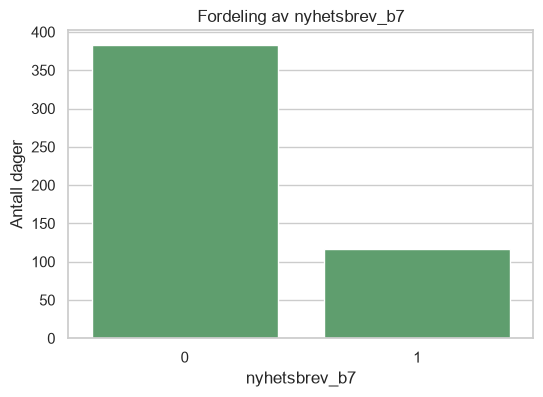

In [28]:
# Fordeling av nyhetsbrev_b7 (0/1)
if "nyhetsbrev_b7" in df.columns:
    counts = df["nyhetsbrev_b7"].value_counts(dropna=False).sort_index()
    print(counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=df["nyhetsbrev_b7"], color="#55A868")
    plt.title("Fordeling av nyhetsbrev_b7")
    plt.xlabel("nyhetsbrev_b7")
    plt.ylabel("Antall dager")
    plt.show()
else:
    print("Kolonnen nyhetsbrev_b7 finnes ikke i df.")

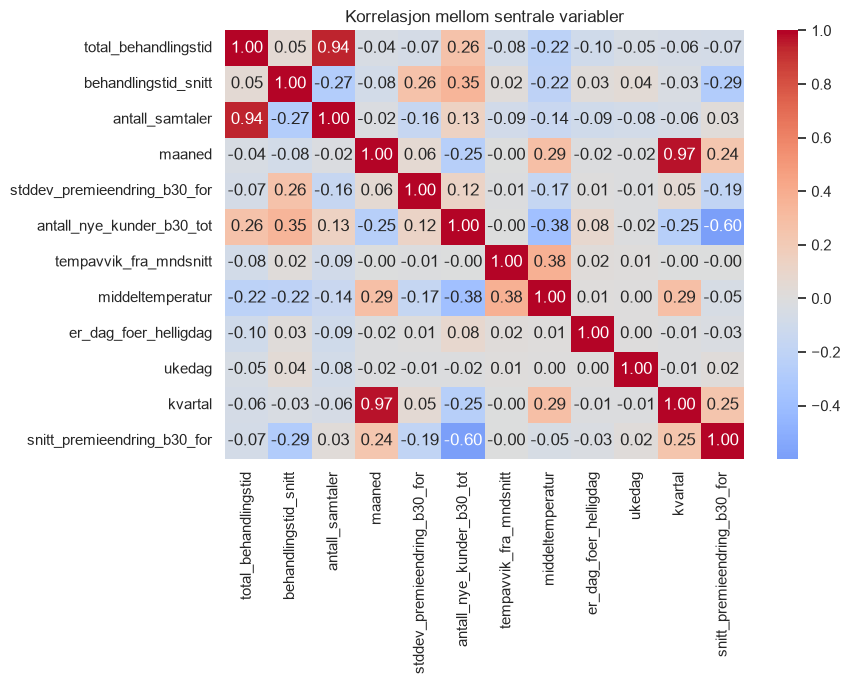

In [29]:
# Enkel korrelasjonsoversikt for sentrale numeriske kolonner
corr_cols = ['total_behandlingstid',
             'behandlingstid_snitt',
             'antall_samtaler',
             'maaned',
             'stddev_premieendring_b30_for',
             'antall_nye_kunder_b30_tot',
             'tempavvik_fra_mndsnitt',
             'middeltemperatur',
             'er_dag_foer_helligdag',
             'ukedag',
             'kvartal',
             'snitt_premieendring_b30_for'
]

corr_cols = [col for col in corr_cols if col in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelasjon mellom sentrale variabler")
plt.tight_layout()
plt.show()

In [30]:
# Sjekk om kvartal er korrekt bestemt av maaned
month_to_quarter = ((df["maaned"] - 1) // 3) + 1

check = pd.DataFrame({
    "maaned": df["maaned"],
    "kvartal": df["kvartal"],
    "forventet_kvartal": month_to_quarter,
})

print("Alle matcher:", (check["kvartal"] == check["forventet_kvartal"]).all())

# Se eventuelle avvik
check[check["kvartal"] != check["forventet_kvartal"]].head()

Alle matcher: True


,maaned,kvartal,forventet_kvartal


In [31]:
pd.crosstab(df["maaned"], df["kvartal"])

kvartal,1,2,3,4
maaned,,,,
1,43,0,0,0
2,40,0,0,0
3,43,0,0,0
4,0,38,0,0
5,0,38,0,0
6,0,41,0,0
7,0,0,46,0
8,0,0,43,0
9,0,0,43,0


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/67508d80-2b69-484e-ab62-ab263ca94733/saml2?SAMLRequest=nZLBbuIwEIZfJfKeYzsJG8ACKlqEygIlKrCr7c0kA7Vw7KztkLZPvyYUqXtoD3uJIueb8Zf5Z3DzUsrgBMYKrYYowhQFoHJdCHUYou1mGvZQYB1XBZdawRC9gkU3o4HlpazYuHbP6hH%2B1GBd4Bspy9oPQ1QbxTS3wjLFS7DM5Ww9Xi5YjCmrjHY61xJ9KPm6glsLxnnDa0lhhdd7dq5ihDRNg5sEa3MgMaWU0D7x1Bn5duVf%2FD99wkeEds68JzyevbvdCnUZwVdauwtk2f1mk4XZar1BwfiqeqeVrUswazAnkcP2cXERsN7gWMa9KI1w4%2BcWQm10BZi%2F1QawVbrZS36EXJdV7Xx37N%2FIHgoi9UH4AcwmQ1QdRVGqefehWnKzzbb3y9U8my5Pu9Xv8dPqljeLSi7Xqx%2Fz7S9RZp0cBT%2BvCcfnhGfW1jBT51ydP6JxGtJuGNENTVkcsyjCSZQ8oWDi%2FYTirq28yrceuBS50VbvnVZSKGgt0%2B532it6NIx3aT%2Fs9DoQ8l0a%2B0ecJjnvd7pJQs5px%2BiyQawVMaP%2FncuAfOzyvpQPPqfZJNNS5K%2FBVJuSu89jjHDUnogi3Lcog5ILOS4KA9b6OKXUzZ0B7vzuO1MDIqPLrf9u%2F%2Bgv&RelayState=ver%3A3-hint%3A197401153138694-ETMsDgAAAZ9KsNdxABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEIWeagxYEopqFAwh6nCy8c4AAACQzMPBtDHSgCQs